# HS4002 Week 1 Demo

## Basics of Python

We're working within the **pandas** + **plotnine** framework.

We'll explore a toy dataset about *Love Is Blind* contestants to answer: **to what extent does age, gender, and race affect the likelihood of marriage in LIB?**

In [1]:
import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [2]:
file_location = "lib_toy.csv"
df = pd.read_csv(file_location)

# What does a dataset usually look like?

In [3]:
df.head()

,Name,Season,Partner,Age,Married,Race,Gender,Unnamed: 7
0,Lauren Speed,1,Cameron Hamilton,32,1,Black,1,LIB + Lauren Speed
1,Cameron Hamilton,1,Lauren Speed,28,1,White,0,LIB + Cameron Hamilton
2,Amber Pike,1,Matthew Barnett,27,1,White,1,LIB + Amber Pike
3,Matthew Barnett,1,Amber Pike,27,1,White,0,LIB + Matthew Barnett
4,Giannina Gibelli,1,Damian Powers,25,0,Hispanic,1,LIB + Giannina Gibelli


# Univariate Analysis

In [4]:
df.describe()

,Season,Age,Married,Gender
count,120.000000,120.000000,120.000000,120.000000
mean,5.650000,30.708333,0.266667,0.500000
std,2.972281,3.090772,0.444071,0.502096
min,1.000000,24.000000,0.000000,0.000000
25%,3.000000,28.000000,0.000000,0.000000
50%,6.000000,31.000000,0.000000,0.500000
75%,8.000000,33.000000,1.000000,1.000000
max,10.000000,39.000000,1.000000,1.000000


In [5]:
df['Race'].value_counts()

Race
White       67
Black       33
Hispanic    12
Asian        6
Mixed        2
Name: count, dtype: int64

## How many seasons of LIB are in this dataset?

In [6]:
df['Season'].value_counts()

Season
10    16
4     14
7     14
1     12
2     12
9     12
3     10
5     10
6     10
8     10
Name: count, dtype: int64

## How many contestants got married?

In [7]:
df['Married'].value_counts()

Married
0    88
1    32
Name: count, dtype: int64

## Univariate Plots

Let's make a histogram of the age distribution using `plotnine` — the grammar is identical to ggplot2. Note that column names in `aes()` are quoted strings in Python.

Matplotlib is building the font cache; this may take a moment.


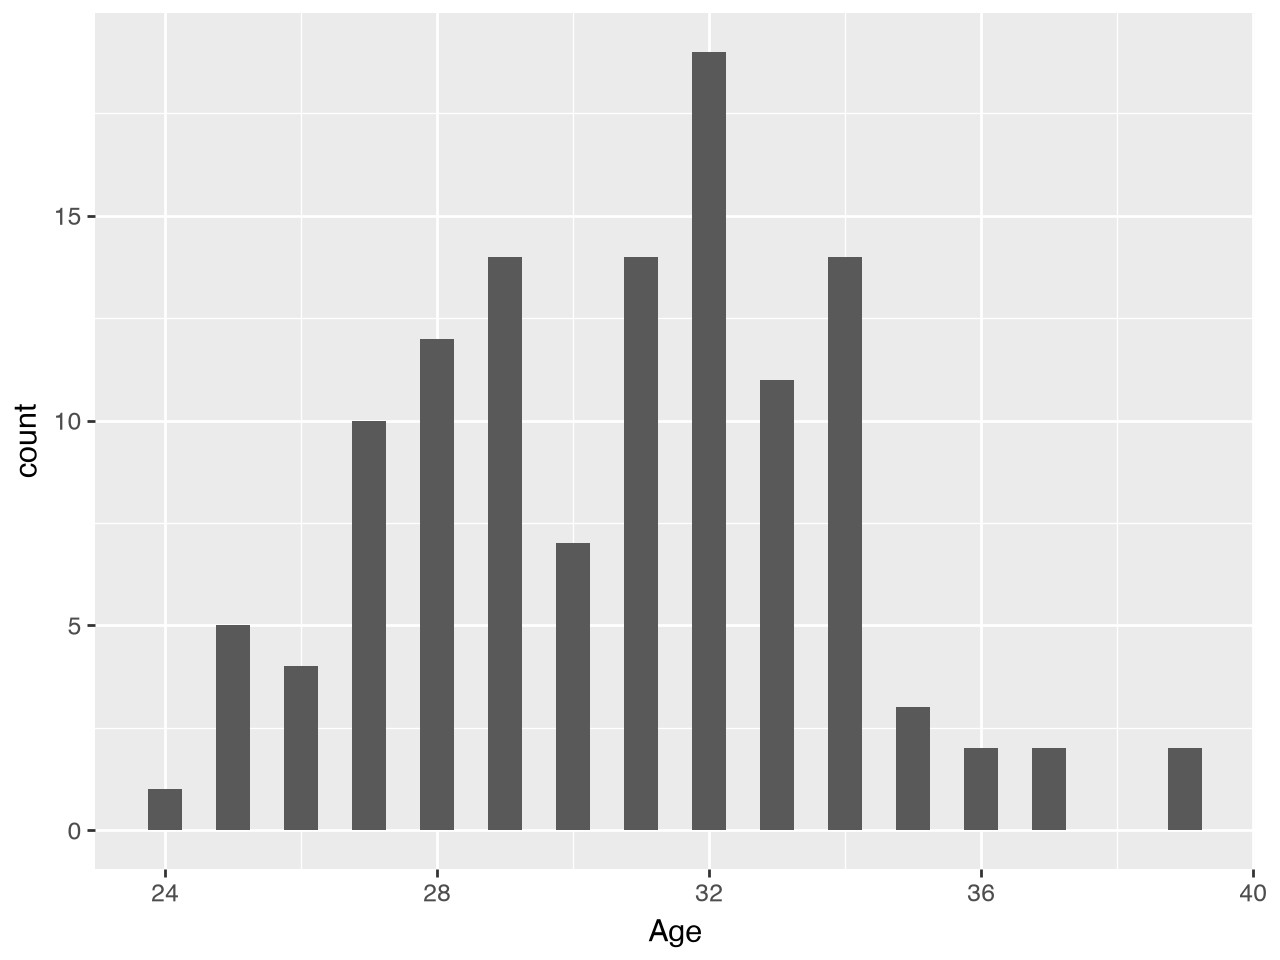

In [8]:
(
    p9.ggplot(df) +
    p9.geom_histogram(p9.aes(x='Age'), binwidth=0.5)
)

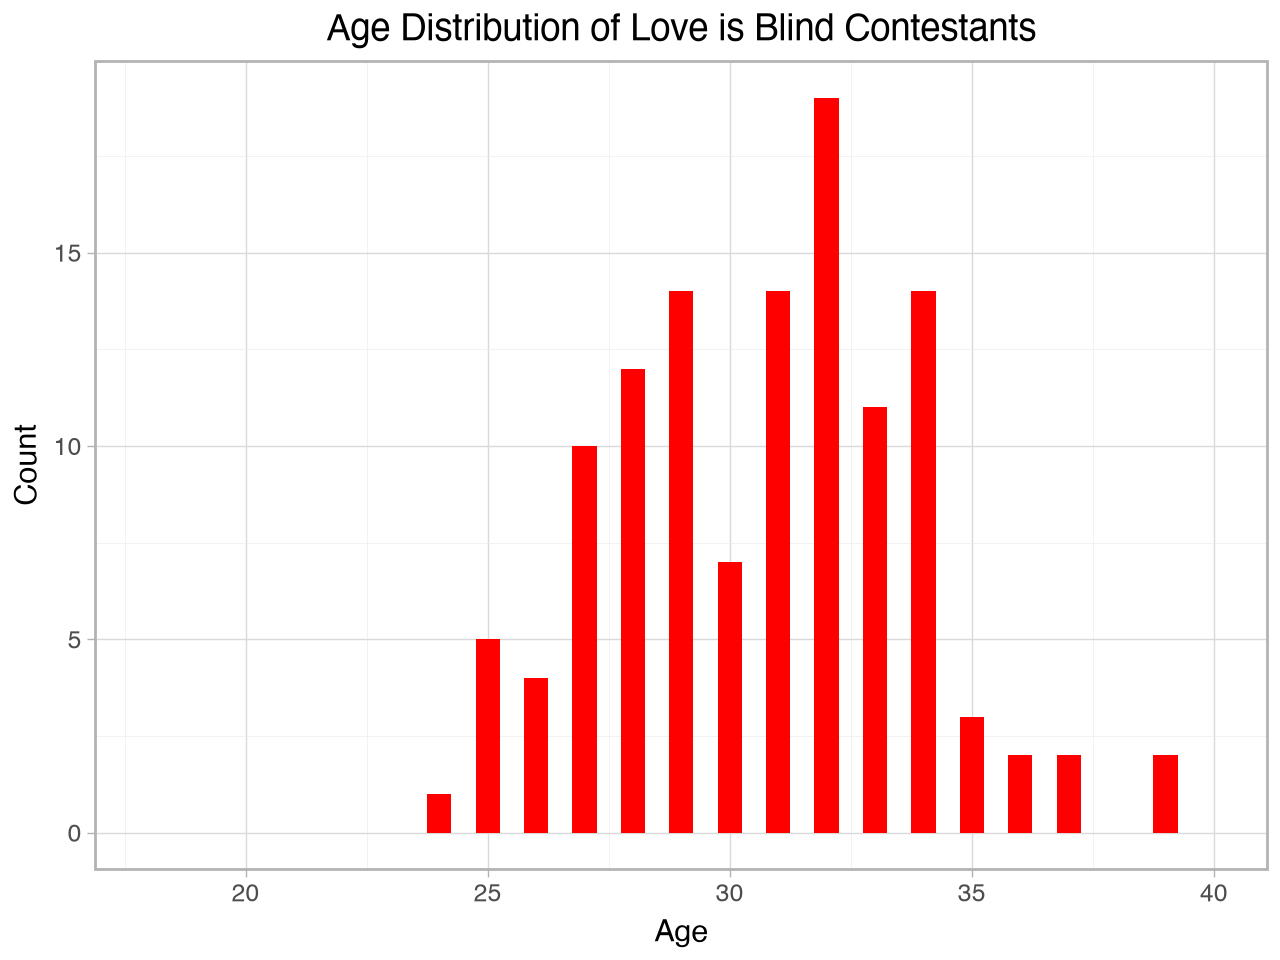

In [11]:
fig_fn = "ntu4eva.png"

p = (
    p9.ggplot(df) +
    p9.geom_histogram(p9.aes(x="Age"), binwidth=0.5, fill="red") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Count", x="Age", title="Age Distribution of Love is Blind Contestants")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

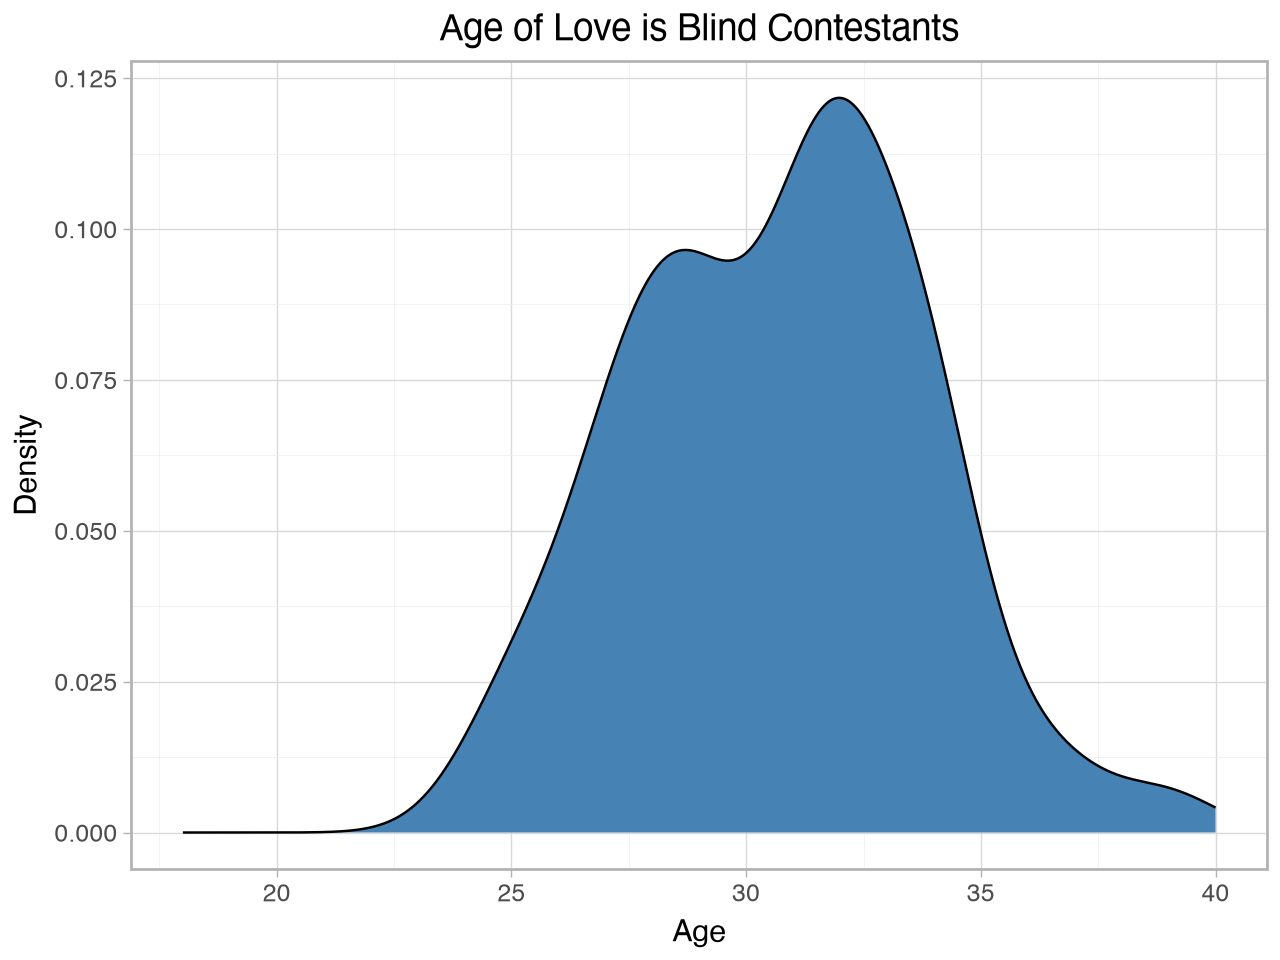

In [12]:
fig_fn = "ntu4eva.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age"), fill="steelblue") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age", title="Age of Love is Blind Contestants")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

# Does Age Matter?

How does age relate to the likelihood of a contestant getting married?

In [ ]:
df.groupby('Married')['Age'].mean()

In [ ]:
fig_fn = "age_by_maritalstatus.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age", fill="factor(Married)"), position="identity", alpha=0.5) +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age",
         title="Age Distribution of Love is Blind Contestants",
         fill="Married")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

# Let's Throw Race Into the Mix

In [ ]:
df.groupby(['Married', 'Race'])['Age'].mean()

In [ ]:
fig_fn = "age_marital_race.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age", fill="factor(Married)"), position="identity", alpha=0.5) +
    p9.facet_wrap("Race") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age",
         title="Age Distribution of Love is Blind Contestants",
         fill="Married")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

# Trying Adding Gender!

In [ ]:
df = df.assign(Gender=np.where(df['Gender'] == 1, 'Woman', 'Man'))

df.groupby(['Married', 'Gender'])['Age'].mean()

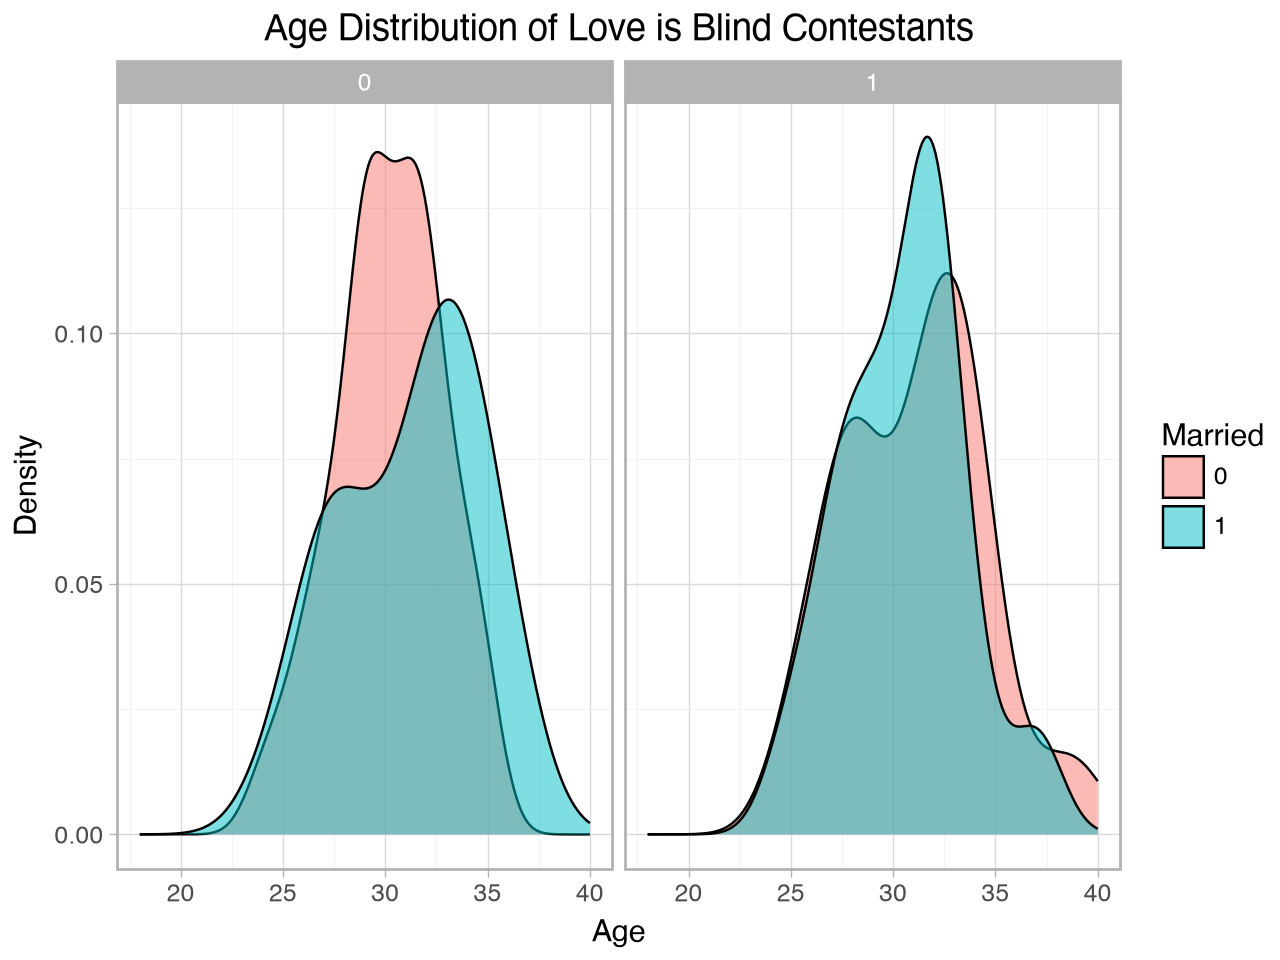

In [13]:
fig_fn = "age_marital_gender.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age", fill="factor(Married)"), position="identity", alpha=0.5) +
    p9.facet_wrap("Gender") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age",
         title="Age Distribution of Love is Blind Contestants",
         fill="Married")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

Testing to see how many apple slices can be forced here lmao